Analyzing Students Performance Dataset
----------------------------------------------------------------------

This data approach student achievement in secondary education of two Portuguese schools. The data attributes include student grades, demographic, social and school related features) and it was collected by using school reports and questionnaires. Two datasets are provided regarding the performance in two distinct subjects: Mathematics (mat) and Portuguese language (por). In [Cortez and Silva, 2008], the two datasets were modeled under binary/five-level classification and regression tasks. Important note: the target attribute G3 has a strong correlation with attributes G2 and G1. This occurs because G3 is the final year grade (issued at the 3rd period), while G1 and G2 correspond to the 1st and 2nd period grades. It is more difficult to predict G3 without G2 and G1, but such prediction is much more useful (see paper source for more details).

Importing Libraries and Datasets
----------------------------------------------------------------------

In [102]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns; sns.set_theme()


In [103]:
students_mat = pd.read_csv('../Dataset/student-mat.csv')

In [104]:
students_mat.head() 

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


Checking for Missing Values
-

In [105]:
students_mat.isnull().sum()

school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64

Describing the Dataset
---------------------------------------------

In [106]:
students_mat.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


Extra Paid Classes Data Distribution
-

Extra paid classes within the course subject

paid
no     214
yes    181
Name: count, dtype: int64


C:\Users\User\AppData\Local\Temp\ipykernel_10352\3722921686.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=students_mat, x='paid', palette='coolwarm' )


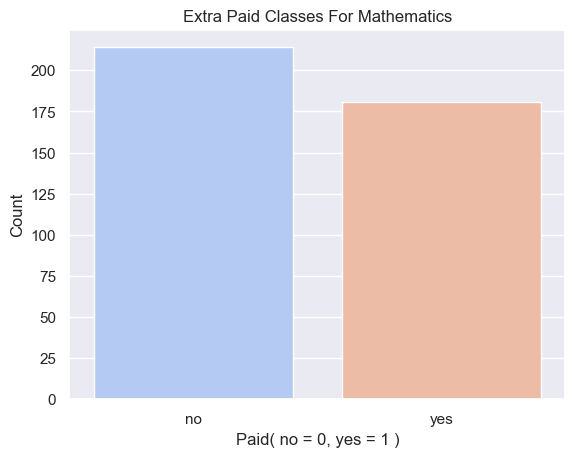

In [107]:
print(students_mat['paid'].value_counts())
sns.countplot(data=students_mat, x='paid', palette='coolwarm' )
plt.xlabel('Paid( no = 0, yes = 1 )')
plt.ylabel('Count')
plt.title('Extra Paid Classes For Mathematics')
plt.show()


Students Health Data Distribution
-

Current health status (numeric: from 1 - very bad to 5 - very good)

health
5    146
3     91
4     66
1     47
2     45
Name: count, dtype: int64


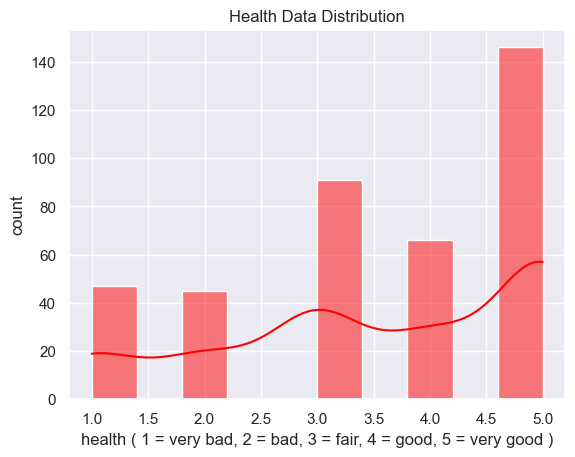

In [108]:
print(students_mat['health'].value_counts())

sns.histplot(data=students_mat, x='health', kde=True, color='red')
plt.title('Health Data Distribution')
plt.xlabel('health ( 1 = very bad, 2 = bad, 3 = fair, 4 = good, 5 = very good )')
plt.ylabel('count')
plt.show()

Study Time Data Distribution
-

Weekly study time (numeric: 1 - <2 hours, 2 - 2 to 5 hours, 3 - 5 to 10 hours, or 4 - >10 hours)

studytime
2    198
1    105
3     65
4     27
Name: count, dtype: int64


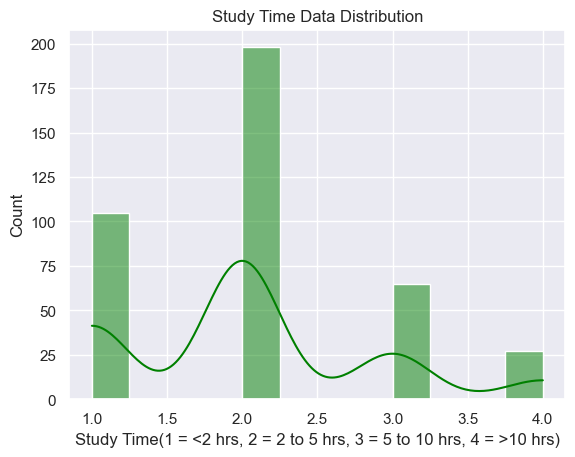

In [109]:
print(students_mat['studytime'].value_counts())

sns.histplot(data=students_mat, x='studytime', kde=True, color='green')

plt.title('Study Time Data Distribution')
plt.xlabel('Study Time(1 = <2 hrs, 2 = 2 to 5 hrs, 3 = 5 to 10 hrs, 4 = >10 hrs)')
plt.ylabel('Count')
plt.show()

Travel Time Data Distribution
-

Home to school travel time (numeric: 1 - <15 min., 2 - 15 to 30 min., 3 - 30 min. to 1 hour, or 4 - >1 hour)

traveltime
1    257
2    107
3     23
4      8
Name: count, dtype: int64


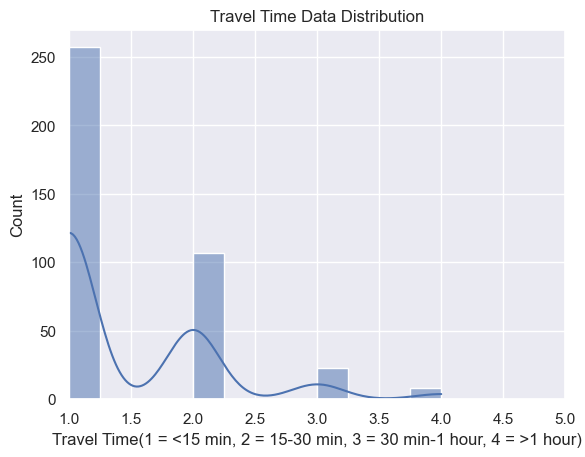

In [110]:
print(students_mat['traveltime'].value_counts())

sns.histplot(data=students_mat, x='traveltime', kde=True)

plt.xlim(1, 5)
plt.title('Travel Time Data Distribution')
plt.xlabel('Travel Time(1 = <15 min, 2 = 15-30 min, 3 = 30 min-1 hour, 4 = >1 hour)')
plt.ylabel('Count')
plt.show()

Target Variable Distribution
-

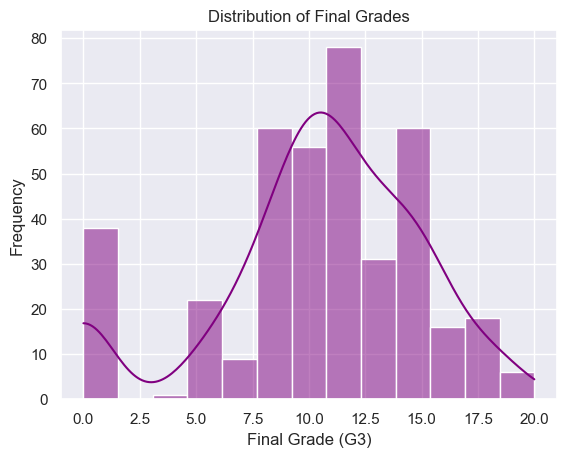

In [111]:
sns.histplot(data=students_mat, x='G3', kde=True, color='purple')
plt.xlabel('Final Grade (G3)')
plt.ylabel('Frequency')
plt.title('Distribution of Final Grades')
plt.show()

Effect of Study Time on Final Grade Distribution
-

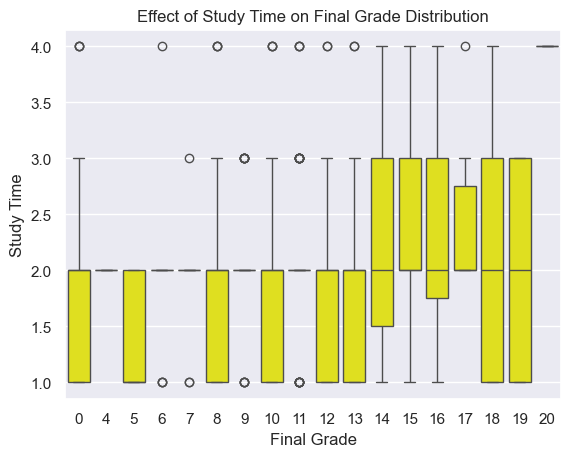

In [112]:
sns.boxplot(data=students_mat, x='G3', y='studytime', color='yellow')
plt.title('Effect of Study Time on Final Grade Distribution')
plt.xlabel('Final Grade')
plt.ylabel('Study Time')
plt.show()


Handling Categorical Data
-

Encoding categoricals to numbers so the model can process them

In [113]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

categorical_col = ['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']

for col in categorical_col:
    students_mat[col] = le.fit_transform(students_mat[col])

Correlation With Target Variable
-

HeatMap correlation with target variable

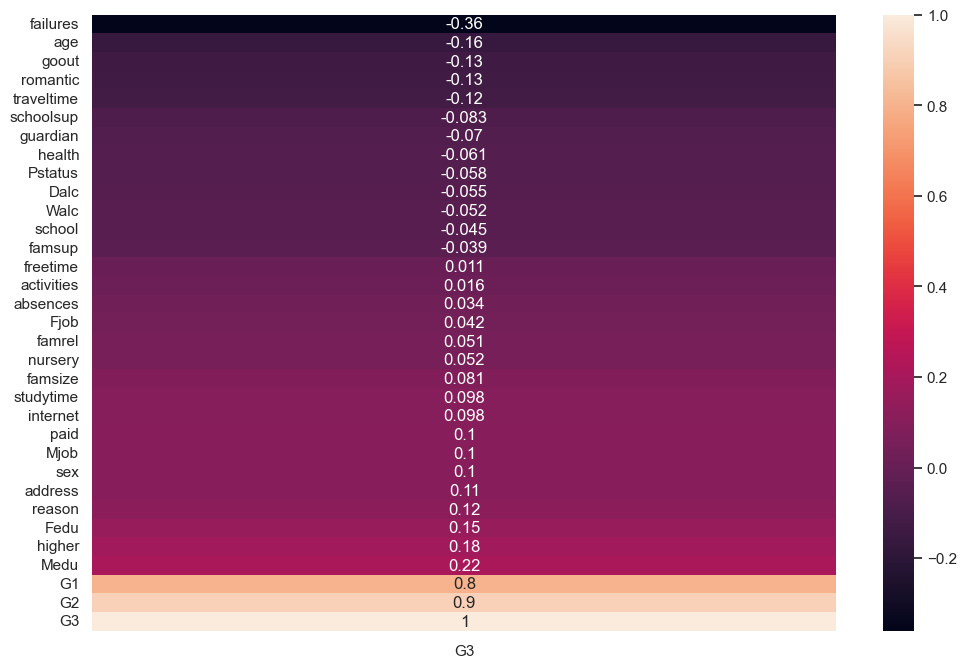

In [114]:
corr = students_mat.corr()
plt.figure(figsize=(12, 8))
sns.heatmap(corr[['G3']].sort_values('G3'), annot=True)
plt.show()

Feature Selection and Data Splitting
-

In [115]:
from sklearn.model_selection import train_test_split

X = students_mat.drop(['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'guardian', 'G3', 'famrel', 'Dalc', 'Walc', 'internet', 'higher'], axis=1)
y = students_mat['G3']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, train_size=0.75, random_state=42)

Feature Scaling
-

In [116]:
from sklearn.preprocessing import StandardScaler

ss = StandardScaler()

X_train = ss.fit_transform(X_train)
X_test = ss.transform(X_test)

Model training and Prediction
-

Since the Dataset is a (Classification and Regression) task, we'll be using LogisticRegression, RandomForestClassifier and Accuracy_Score 

Classification Task
-

In [117]:
# Classification Task

from sklearn.linear_model import LogisticRegression

lr = LogisticRegression().fit(X_train, y_train)

y_pred = lr.predict(X_test)
print(y_pred)

[ 7 13  8 10  8 13 18 10  0 10 15  0 16 12 13 10 10 10 13 10 16 15 15  8
  6 18 10 11 16 10  8 10 14 11  0  8  0 14 12  7  7 10 15 10 15 10 11 13
 15 13 14 14 11  0  8 11 10  8 18 18 12 10  7  0  0 18 10 11  9 18  9 12
 14 18 11  6 12 15  7 15 13  0 11 10  9 11  0 11 13  0 11 10 13 11  0  8
 10 15 15]


Model Evlauation
-

To measure model performance we measure accuracy using accuracy_score fucntion

In [118]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print(f'Model Accuracy: {accuracy:.2f}')

Model Accuracy: 0.23


Regression Task
-

In [119]:
# Regression Task

from sklearn.ensemble import RandomForestClassifier

clf = RandomForestClassifier()
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

print(y_pred)

[10 11  8 10  8 13 18 10  0 15 15  8 15 12 14  8  0 10 15  0 13 15 15  6
  8 18 10  0 15 10  8  8 15 13  0  8  0 14 12 10  9 10 15 10 15 10 11 14
 13 15 14 15 10 10  8 12 10  0 16 15 14 10  8  6  8 15 10 10 11 15  8 10
 14 18 10  8 10 14  5 13 13  0  8  0  8 15  0 11 15  0 13 10 12 10  0  8
  8 15 15]


In [120]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print(f'Model Accuracy: {accuracy:.2f}')

Model Accuracy: 0.41
